## **Decision Tree**

`Goal: - keywords`
- Parametric and non-parametric
- Decision Tree Definition
- Decision Tree Hyperparameters
- Impurity measures - Cost/loss function
    - Entropy
    - Coding:
        - entropy
        - Information Gain
        - Best threshold per feature
    - Gini Impurity


# 

### **`Parametric and non-parametric:`**

- Parametric: model has learned parameters.
- non-parametric: no learned parameters.

***A parametric model assumes a fixed functional form with a finite, fixed number of parameters that doesn’t grow with data size***. Once trained, it summarizes everything in those parameters. Examples: linear/logistic regression, naive Bayes, simple neural nets.

***A non-parametric model makes fewer assumptions about the form and lets complexity (effectively the number of parameters) grow with the data. Examples: k-NN, decision trees, kernel SVMs, Gaussian processes***.

Key contrasts:
•	Assumptions: parametric assumes a specific shape (e.g., linear); non-parametric is flexible.
•	Data needs: parametric works with less data; non-parametric typically needs more.
•	Bias/variance: parametric tends toward higher bias, lower variance; non-parametric the reverse.
•	Speed/memory: parametric is fast and compact at inference; non-parametric can be slower and may store training data.
•	Overfitting risk: lower for parametric (if form is right), higher for non-parametric without regularization.


Note “non-parametric” doesn’t mean no parameters—it means the parameter count isn’t fixed in advance.

#

### **`Decision Tree Definiton:`**

A decision tree is a model that makes predictions by asking a sequence of yes/no questions about the features, splitting the data at each question, until it reaches a leaf that outputs a prediction.

**The structure**

- Root node: the first question, asked of all data.
- Internal nodes: subsequent questions on subsets.
- Branches: the answers (e.g., "amount > $500" → yes/no).
- Leaves: terminal nodes holding a prediction — a class label (classification) or a value (regression, usually the mean of training targets that landed there).

A prediction is just: start at the root, follow the branches your features dictate, return the leaf value.

**How splits are chosen**

At each node, the algorithm searches over (feature, threshold) pairs and picks the one that best separates the data according to an impurity criterion:

*Classification:*

- **Gini impurity:** 1 − Σ pᵢ². **Measures probability of misclassifying a random sample if labeled by class distribution.** Used by CART.
- **Entropy:** −Σ pᵢ log pᵢ. **Information gain = entropy reduction from the split.** Used by ID3/C4.5.

Gini and entropy usually pick similar splits; Gini is slightly faster.

*Regression:*

- MSE / variance reduction. Pick the split that minimizes weighted variance of the children.
- MAE as an alternative.

The split chosen is the one maximizing impurity reduction (parent impurity − weighted average of child impurities), evaluated greedily and locally — no lookahead.

---

#

### **`Decision tree Hyperparameters`**
In Decision Trees, **Hyperparameters** are the configuration settings you choose *before* the training process begins.

Because Decision Trees are prone to **Overfitting** (meaning they become so complex that they memorize the training data but fail on new data), hyperparameters are used to "prune" or constrain the tree.

Here are the most important hyperparameters categorized by their purpose:

---

#### 1. Controlling Tree Complexity (Preventing Overfitting)

These are the most critical settings to prevent the tree from growing infinitely deep and capturing "noise" as if it were a real pattern.

- **`max_depth`**:
    - **What it is:** The maximum number of levels in the tree.
    - **Effect:** A deep tree can capture complex patterns but is highly prone to overfitting. A shallow tree is simpler and more "generalized" but might underfit (be too simple).
    - *Analogy:* How many "levels" of questions you are allowed to ask.
- **`min_samples_split`**:
    - **What it is:** The minimum number of data points required in a node before it can be split again.
    - **Effect:** If this is set to 10, and a node only has 7 samples, the tree will stop splitting there. Higher values prevent the tree from creating tiny, specific branches for single outliers.
- **`min_samples_leaf`**:
    - **What it is:** The minimum number of data points required to be in a "leaf" (an endpoint).
    - **Effect:** This ensures that no prediction is made based on a group that is too small. It smooths the model, making it more robust to noise.

---

#### 2. Controlling Feature Selection

These settings determine how the algorithm evaluates which features are "good."

- **`criterion`**:
    - **What it is:** The mathematical function used to measure the quality of a split.
    - **Options:**
        - `gini`: Uses Gini Impurity (faster to calculate).
        - `entropy`: Uses Information Gain (more computationally expensive but can result in more balanced trees).
- **`max_features`**:
    - **What it is:** The number of features the tree is allowed to consider when looking for the best split.
    - **Effect:** Instead of looking at all 100 columns in your data, you might tell the tree to only look at 10 random columns at each split. This is a key technique used in **Random Forests** to increase diversity and reduce overfitting.

---

#### 3. Summary Cheat Sheet for Tuning

If you are experiencing specific problems with your model, here is how you should adjust your hyperparameters:

| If your model is... | Problem Type | Strategy | Hyperparameter Adjustment |
| --- | --- | --- | --- |
| **Too complex** (High training accuracy, Low test accuracy) | **Overfitting** | **Constrain the tree** | $\downarrow$ `max_depth`<br>$\uparrow$ `min_samples_split`<br>$\uparrow$ `min_samples_leaf` |
| **Too simple** (Low training accuracy, Low test accuracy) | **Underfitting** | **Allow more complexity** | $\uparrow$ `max_depth`<br>$\downarrow$ `min_samples_split`<br>$\downarrow$ `min_samples_leaf}$ |

#### Pro-Tip: The "Pruning" Concept

In advanced machine learning, we often use a technique called **Cost Complexity Pruning** (often represented by the hyperparameter `ccp_alpha`).

Instead of manually setting a depth, `ccp_alpha` penalizes the tree for having too many leaves. It essentially says: *"I will allow this extra branch only if it improves the accuracy significantly enough to overcome the 'penalty' cost."*

#

### **`Entropy`**

- Entropy measures ‘disorder’ or ‘unpredictability’
- In Information theory, Entropy tells us how much ‘information’ we gain by splitting a dataset. A high entropy means the data is very messy (random), while an entropy of 0 means the data is perfectly organized.
- an Example:
    
    While **Gini Impurity** measures "how often a random element would be incorrectly labeled," **Entropy** measures **"disorder"** or **"unpredictability."**
    
    In Information Theory, Entropy tells us how much "information" we gain by splitting a dataset. A high entropy means the data is very messy (random), while an entropy of 0 means the data is perfectly organized.
    
    ---
    
    #### The Scenario: Predicting if a Student Passes an Exam
    
    We have a class of **10 students**. We want to see if knowing their **"Study Hours"** helps us predict if they **Pass** or **Fail**.
    
    #### Initial State (The Root Node)
    
    - **Passed:** 5 students
    - **Failed:** 5 students
    - **Total ($N$):** 10
    
    **Step 1: Calculate Entropy of the Root Node**
    The formula for Entropy is:
    $$Entropy = -\sum P_i \log_2(P_i)$$
    
    1. Probability of Passing ($P_{pass}$) = $5/10 = 0.5$
    2. Probability of Failing ($P_{fail}$) = $5/10 = 0.5$
    3. $Entropy_{root} = -[ (0.5 \times \log_2(0.5)) + (0.5 \times \log_2(0.5)) ]$
    
    *Note: $\log_2(0.5)$ is $-1$.*
    
    1. $Entropy_{root} = -[ (0.5 \times -1) + (0.5 \times -1) ]$
    2. $Entropy_{root} = -[ -0.5 - 0.5 ] = \mathbf{1.0}$
    
    **Interpretation:** An entropy of **1.0** is the maximum possible disorder for a binary classification. It means we have no idea if a student will pass or fail just by looking at the group; it's a perfect 50/50 coin toss.
    
    ---
    
    #### The Decision: Testing a Split
    
    Now, we split the students into two groups based on **Study Hours**: **"High Study"** and **"Low Study."**
    
    #### Group A: High Study (Total: 4)
    
    - **Passed:** 4
    - **Failed:** 0
    1. $P_{pass} = 4/4 = 1.0$
    2. $P_{fail} = 0/4 = 0$
    3. $Entropy_{high} = -[ (1 \times \log_2(1)) + (0 \times \log_2(0)) ]$
    *(Note: $\log_2(1) = 0$, and by convention, $0 \times \text{anything} = 0$)*
    4. $Entropy_{high} = -[ 0 + 0 ] = \mathbf{0}$ (This group is **Pure**)
    
    #### Group B: Low Study (Total: 6)
    
    - **Passed:** 1
    - **Failed:** 5
    1. $P_{pass} = 1/6 \approx 0.167$
    2. $P_{fail} = 5/6 \approx 0.833$
    3. $Entropy_{low} = -[ (0.167 \times \log_2(0.167)) + (0.833 \times \log_2(0.833)) ]$
    4. $Entropy_{low} \approx -[ (0.167 \times -2.58) + (0.833 \times -0.26) ]$
    5. $Entropy_{low} \approx -[ -0.43 - 0.21 ] = \mathbf{0.64}$
    
    ---
    
    #### Step 2: Calculate Information Gain
    
    The goal of the Decision Tree is to maximize **Information Gain**. This is the reduction in entropy after the split.
    
    $$\text{Information Gain} = Entropy_{root} - \text{Weighted } Entropy_{split}$$
    
    1. **Weight of High Study group:** $4/10 = 0.4$
    2. **Weight of Low Study group:** $6/10 = 0.6$
    3. **Weighted Entropy:** $(0.4 \times 0) + (0.6 \times 0.64) = \mathbf{0.384}$
    4. **Information Gain:** $1.0 - 0.384 = \mathbf{0.616}$
    
    #### Summary Comparison
    
    | Metric | Root Node (50/50) | Pure Node (100/0) | Mixed Node (High uncertainty) |
    | --- | --- | --- | --- |
    | **Gini Impurity** | 0.50 | 0.00 | Approaches 0.50 |
    | **Entropy** | 1.00 | 0.00 | Approaches 1.00 |
    
    **Key takeaway:**
    
    - If the split results in a high **Information Gain** (like our $0.616$ above), the tree will choose this feature to branch on.
    - The "High Study" group became much more predictable, reducing the total chaos of the system.

In [3]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

`Calculate Entropy:`

In [4]:
# define entropy function
def entropy(distribution):
    h = 0.0 # store entropy
    for probability in distribution:
        if probability > 0: 
            logprob = np.log2(probability)
        h -= probability * logprob
    return h

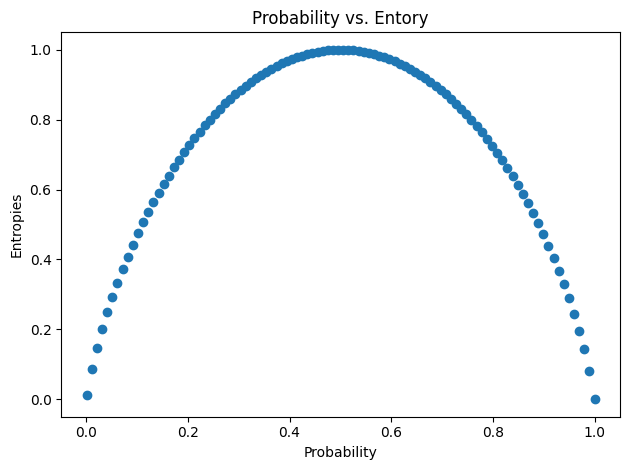

In [5]:
# calcualte the entropy for two classes
p_list = np.linspace(0.001, 1, 100) # avoid p = 0
entropies = [entropy([p, 1-p]) for p in p_list]

plt.scatter(p_list, entropies)
plt.xlabel('Probability')
plt.ylabel('Entropies')
plt.title('Probability vs. Entory')
plt.tight_layout()
plt.show()

As you can see, for the two classes, as then are close to even distribution (0.5, 0.5), the Entropy is highest 1.

`Calculate the probability`

In [6]:
def get_label_distribution(labels): # labels is the counts of each class after the tree split
    values, counts = np.unique(labels, return_counts=True)
    label_probs = counts/counts.sum()
    return label_probs

`Calculate the Entropy:`

In [8]:
labels = [0, 1, 1, 0, 2, 1, 2, 1, 1]
entropy(get_label_distribution(labels))

np.float64(1.4355205042826666)

`sklearn - decision tree`

In [82]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import graphviz
import pydotplus
from IPython.display import Image

In [83]:
# load the data
iris = datasets.load_iris()
data = iris.data
labels = iris.target
features = iris.target_names

In [84]:
# split data to train and test, train the model
X_train, X_test, y_train, y_test = train_test_split(data, labels, stratify = labels, test_size=0.25)

dt = DecisionTreeClassifier(
    criterion = 'entropy',
    max_depth=2,
    random_state=0
)

dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [85]:
# feature importance
feature_importance = dt.feature_importances_

# accuracy
accuracy = dt.score(X_train, y_train)

print(f'feature importance: {feature_importance}, accuracy: {accuracy:4f}')

feature importance: [0.         0.         0.35740739 0.64259261], accuracy: 0.973214


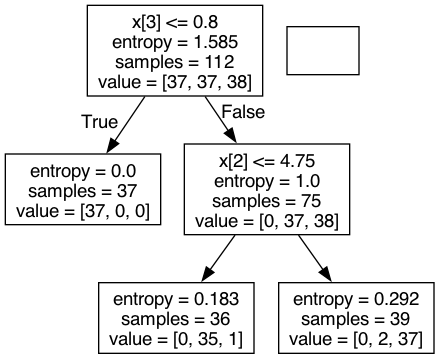

In [86]:
# visualize the trained tree with max_depth = 2
dot_data = tree.export_graphviz(dt, out_file=None)
graph = pydotplus.graph_from_dot_data(dot_data)
display(Image(graph.create_png()))

from the chart 
- the x[3] means spit the data by fourth feature with index as 3.
- root's rule is x[3] <= 0.8, second level's rule is x[2] <= 4.75

`find the best split point`
- Below code is generated by Gemma4, but we can learn the logics and steps:
    - create function to calculate the entropy
    - create function to calculate the information gain
    - create function to find the best threshold by loop over threshold values
    - loop over all features - find the best threshold for each feature

In [64]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

def calculate_entropy(target_series):
    """Calculates the entropy of a single series."""
    if len(target_series) == 0:
        return 0
    probabilities = target_series.value_counts(normalize=True)
    return -np.sum(probabilities * np.log2(probabilities))

def calculate_information_gain(df, feature_name, target_name, threshold):
    """Calculates IG for a specific numerical threshold."""
    parent_entropy = calculate_entropy(df[target_name])
    total_samples = len(df)
    
    # Binary split based on threshold
    left_split = df[df[learn_feature] <= threshold][target_name]
    right_split = df[df[learn_feature] > threshold][target_name]
    
    if len(left_split) == 0 or len(right_split) == 0:
        return 0 # Skip thresholds that don't actually split the data
    
    weight_left = len(left_split) / total_samples
    weight_right = len(right_split) / total_samples
    
    weighted_child_entropy = (weight_left * calculate_entropy(left_split)) + \
                              (weight_right * calculate_entropy(right_split))
    
    return parent_entropy - weighted_child_entropy

def find_best_threshold(df, feature_name, target_name):
    """
    Iterates through all possible midpoints in a numerical column 
    to find the threshold that maximizes Information Gain.
    """
    # 1. Get sorted unique values of the feature
    sorted_values = np.sort(df[feature_name].unique())
    
    # 2. Calculate midpoints between all consecutive values as potential thresholds
    # Example: if values are [1, 2, 5], midpoints are [1.5, 3.5]
    thresholds = (sorted_values[:-1] + sorted_values[1:]) / 2
    
    best_gain = -1
    best_thresh = None
    
    # 3. Test every threshold
    for thresh in thresholds:
        # We use a helper variable name to avoid scope issues in the function above
        global learn_feature 
        learn_feature = feature_name 
        
        current_gain = calculate_information_gain(df, feature_name, target_name, thresh)
        
        if current_gain > best_gain:
            best_gain = current_gain
            best_thresh = thresh
            
    return best_thresh, best_gain

# --- MAIN EXECUTION ---

# 1. Load Iris Dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

print("Iris dataset loaded successfully.\n")

# 2. Test for each numerical feature
results = []

for col in iris.feature_names:
    best_t, best_g = find_best_threshold(df, col, 'target')
    results.append({
        'Feature': col,
        'Best Threshold': round(best_t, 4),
        'Max Info Gain': round(best_g, 4)
    })

# 3. Display Results
results_df = pd.DataFrame(results)
print("Optimization Results:")
print(results_df.to_string(index=False))

# 4. Interpretation
top_feature = results_df.loc[results_df['Max Info Gain'].idxmax()]
print(f"\nConclusion: The best feature to split the data is '{top_feature['Feature']}' "
      f"at a threshold of {top_feature['Best Threshold']}.")


Iris dataset loaded successfully.

Optimization Results:
          Feature  Best Threshold  Max Info Gain
sepal length (cm)            5.55         0.5572
 sepal width (cm)            3.35         0.2831
petal length (cm)            2.45         0.9183
 petal width (cm)            0.80         0.9183

Conclusion: The best feature to split the data is 'petal length (cm)' at a threshold of 2.45.


#

### **`Gini Imputiry`**

- used to measure how often a random element would be incorrectly labeled.

To understand **Gini Impurity**, think of it as a measure of "chaos" or "uncertainty" in a dataset.

- **Pure Node:** All items belong to one class (Gini = 0).
- **Impure Node:** Items are mixed between different classes (Gini approaches 0.5 for two classes).

Here is a step-by-step mathematical example.

---

#### The Scenario: Predicting if a Fruit is an Orange or a Lemon

Imagine we have a dataset of **10 fruits**. We want to decide whether to split them based on **Color** (Bright vs. Dull) to create the most "pure" groups possible.

#### Initial State (The Root Node)

Before any split, our dataset looks like this:

- **Oranges:** 6
- **Lemons:** 4
- **Total ($N$):** 10

**Step 1: Calculate Gini Impurity of the Root Node**
The formula for Gini Impurity is:
$$Gini = 1 - \sum (P_i)^2$$
*(Where $P_i$ is the probability/proportion of each class)*

1. Probability of Orange ($P_{orange}$) = $6/10 = 0.6$
2. Probability of Lemon ($P_{lemon}$) = $4/10 = 0.4$
3. $Gini_{root} = 1 - (0.6^2 + 0.4^2)$
4. $Gini_{root} = 1 - (0.36 + 0.16) = \mathbf{0.48}$

---

#### The Decision: Testing a Split

Now, we test a feature: **Color**. We split the fruits into two groups: **Bright** and **Dull**.

#### Group A: Bright Fruits (Total: 5)

- Oranges: 5
- Lemons: 0
- $Gini_{bright} = 1 - [(5/5)^2 + (0/5)^2] = 1 - [1 + 0] = \mathbf{0}$ (This is a **Pure** node)

#### Group B: Dull Fruits (Total: 5)

- Oranges: 1
- Lemons: 4
- $Gini_{dull} = 1 - [(1/5)^2 + (4/5)^2] = 1 - [0.04 + 0.64] = \mathbf{0.32}$

---

#### Step 2: Calculate the Weighted Gini Impurity of the Split

To decide if this "Color" split is good, we calculate the **Weighted Average** of the impurities of the resulting nodes. We weight them by how many items went into each group.

$$\text{Gini}*{split} = \left( \frac{N*{bright}}{N_{total}} \times Gini_{bright} \right) + \left( \frac{N_{dull}}{N_{total}} \times Gini_{dull} \right)$$

1. Weight of Bright group: $5/10 = 0.5$
2. Weight of Dull group: $5/10 = 0.5$
3. $\text{Gini}_{split} = (0.5 \times 0) + (0.5 \times 0.32)$
4. $\text{Gini}_{split} = 0 + 0.16 = \mathbf{0.16}$

---

#### Conclusion: The Decision

To find the best split, the algorithm compares the **Gini Gain** (Reduction in impurity).

- **Original Gini:** 0.48
- **New Gini after Split:** 0.16
- **Improvement (Gain):** $0.48 - 0.16 = \mathbf{0.32}$

**The Decision Tree Logic:**
If the algorithm calculates another feature (e.g., "Size") and that split results in a Gini of **0.25**, it will **reject** the Size split and **choose** the Color split, because $0.16$ is lower (less impure) than $0.25$.

#### Summary Table
| Node | Oranges | Lemons | Total | Gini Impurity |
| --- | --- | --- | --- | --- |
| **Root** | 6 | 4 | 10 | **0.48** |
| **Bright (Split)** | 5 | 0 | 5 | **0.00** |
| **Dull (Split)** | 1 | 4 | 5 | **0.32** |
| **Weighted Result** |  |  |  | **0.16** |